In [1]:
import sys
sys.path.append('/workspaces/EstructuraDatos_2026_01')

In [2]:
from Goodrich.ch08.linked_binary_tree import *

In [5]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 44.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 42.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 41.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 47.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 18.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [7]:
def construir(L):
    LB = LinkedBinaryTree()

    if len(L) == 0:
        return LB

    root = LB._add_root(L[0])

    def ramas(nodo_actual, posicion_en_lista):
        indiiz = 2 * posicion_en_lista + 1
        indider = 2 * posicion_en_lista + 2


        if indiiz < len(L):
            l = LB._add_left(nodo_actual, L[indiiz])
            ramas(l, indiiz)

        if indider < len(L):
            r = LB._add_right(nodo_actual, L[indider])
            ramas(r, indider)

    ramas(root, 0)

    return LB

In [9]:
def dibujar(T):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')

    posiciones = {}
    elementos  = {}
    padres     = {}

    colores_lineas = ['red', 'green', 'orange', 'purple', 'gray', 'pink', 'blue']
    color_arista   = {}
    contador       = [0]

    def calcular_xy(p, x, y, espacio): 

        if p is None or p.element() is None:
            return 
        
        nodo = p._node
        posiciones[nodo] = (x, y)
        elementos[nodo]  = p.element()
        padre = T.parent(p)
        if padre is not None:
          padres[nodo] = padre._node   
        else:
          padres[nodo] = None


        if padres[nodo] is not None:
            color_arista[nodo] = colores_lineas[contador[0] % len(colores_lineas)]
            contador[0] += 1

        calcular_xy(T.left(p),  x - espacio, y - 1, espacio / 2)
        calcular_xy(T.right(p), x + espacio, y - 1, espacio / 2)

    calcular_xy(T.root(), x=0, y=0, espacio=4)


    for nodo, (x, y) in posiciones.items():
        nodo_padre = padres[nodo]
        if nodo_padre is not None:
            xp, yp = posiciones[nodo_padre]
            color = color_arista[nodo]
            ax.plot([x, xp], [y, yp], color=color, linewidth=2, zorder=1)


    for nodo, (x, y) in posiciones.items():
        color = color_arista.get(nodo, 'black')
        ax.plot(x, y, 'o', markersize=8, color=color, zorder=2)
        ax.text(x + 0.15, y, str(elementos[nodo]),
                ha='left', va='center',
                fontsize=11, color=color, fontweight='bold')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2248/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


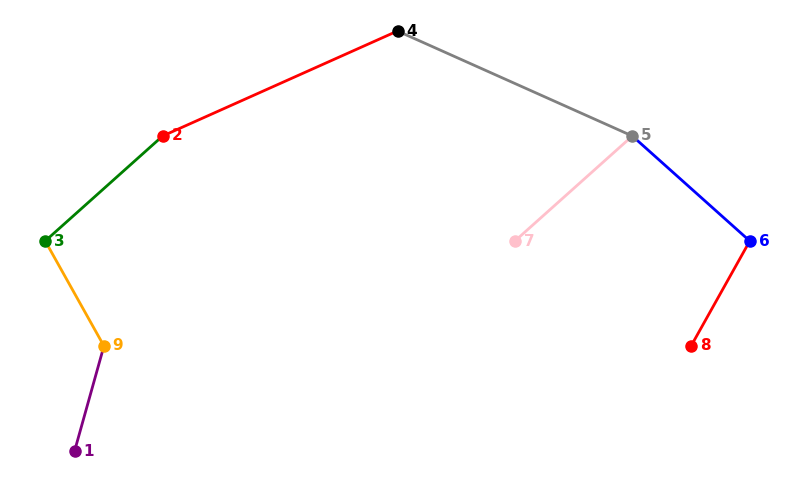

In [10]:
dibujar(construir([4, 2, 5, 3, None, 7, 6, None, 9, None, None, None, None, 8, None, None, None, 1]))